# Análisis Exploratorio y SQL

**Proyecto 0.2 — EDA desde Cero con Datos Sucios**  
Portafolio: De Matemático a Data Scientist

---

**Fuente de datos:** INEC Ecuador — Registro Estadístico de Defunciones Generales 2021  
**Dataset:** `defunciones_2021_limpio.csv` (107,641 filas × 58 columnas, post-limpieza)  
**Objetivo:** Explorar el dataset limpio mediante consultas SQL y visualizaciones estadísticas para extraer patrones demográficos, geográficos y epidemiológicos de la mortalidad en Ecuador en 2021.

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from pathlib import Path

# Configuración visual
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="husl")

# Rutas del proyecto
PATH_PROCESSED = Path("../data/processed")
PATH_FIGURES = Path("../reports/figures")

In [3]:
# Cargar dataset limpio
df = pd.read_csv(PATH_PROCESSED / "defunciones_2021_limpio.csv")

# Verificación rápida
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"Nulos restantes: {df.isnull().sum().sum():,}")

Dimensiones: 107,641 filas × 58 columnas
Memoria: 362.1 MB
Nulos restantes: 391,605


## 1. Estado del dataset limpio

El dataset proviene del pipeline de limpieza del Notebook 02. Contiene 107,641 registros y 58 columnas.

Persisten 391,605 celdas nulas distribuidas en 32 columnas. No son errores de limpieza, son nulos estructurales o datos no registrados en la fuente original:

- **Nulos estructurales:** `muj_fertil`, `mor_viol`, `lug_viol` solo aplican a subpoblaciones (mujeres fértiles y muertes violentas, respectivamente). Es correcto que sean nulos para el resto.
- **Dato no registrado:** `autopsia`, `sabe_leer`, `niv_inst`, `etnia`, `est_civil` — el registro original no incluyó esa información. Los porcentajes van del 2.75% al 32.64%.
- **Clasificaciones CIE parciales:** Algunas agrupaciones de causa de muerte (`causa67A/B`, `causa80`) no tienen mapeo para todas las causas CIE-10, generando 191 nulos (~0.18%).

Las consultas SQL y visualizaciones de este notebook filtran o excluyen nulos según corresponda a cada análisis.

## 2. Carga a SQLite

Se carga el dataset limpio a una base de datos SQLite en memoria para realizar consultas SQL. Se usa SQLite en memoria (`:memory:`) porque el dataset cabe cómodamente en RAM y no se necesita persistencia — el CSV limpio es la fuente de verdad.

In [7]:
# Crear conexión a SQLite en memoria RAM
conn = sqlite3.connect(":memory:") 

# Cargar y convertir el DataFrame completo como tabla SQL llamada "defunciones"
df.to_sql("defunciones", conn, index=False, if_exists="replace")

# Verificar: estructura de la tabla 
print("=/= Estructura de la tabla =/=")
tabla_info = pd.read_sql_query("PRAGMA table_info(defunciones)", conn)
print(f"Columnas registradas: {len(tabla_info)}")
print(f"\nPrimeras 10 columnas:")
print(tabla_info[["cid", "name", "type"]].head(10).to_string(index=False))

# Verificar: conteo de filas
conteo = pd.read_sql_query("SELECT COUNT(*) AS total_filas FROM defunciones", conn)
print(f"\nFilas en SQLite: {conteo['total_filas'].iloc[0]:,}")

=/= Estructura de la tabla =/=
Columnas registradas: 58

Primeras 10 columnas:
 cid       name    type
   0 Numeracion INTEGER
   1  prov_insc    TEXT
   2  cant_insc    TEXT
   3  parr_insc    TEXT
   4  anio_insc    REAL
   5   mes_insc    TEXT
   6   dia_insc    REAL
   7 fecha_insc    TEXT
   8   nac_fall    TEXT
   9   cod_pais    TEXT

Filas en SQLite: 107,641


## 3. Análisis mediante consultas SQL

Cada consulta responde una pregunta analítica específica sobre la mortalidad en Ecuador en 2021. Se ejecutan directamente sobre la tabla `defunciones` en SQLite y los resultados se cargan como DataFrames para su interpretación.

### Consulta 1 — ¿Cuáles fueron las 10 principales causas de muerte?

Se agrupan las defunciones por la descripción de causa en la clasificación de 103 categorías (variable `desc_causa103`), que ofrece un nivel de detalle intermedio entre la causa específica CIE-10 y las agrupaciones más amplias.

In [8]:
query_01 = """
    SELECT
        desc_causa103,
        COUNT(*)                                    AS defunciones,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS porcentaje
    FROM defunciones
    GROUP BY desc_causa103
    ORDER BY defunciones DESC
    LIMIT 10
"""

top10_causas = pd.read_sql_query(query_01, conn)
top10_causas

,desc_causa103,defunciones,porcentaje
0,COVID-19,21002,19.51
1,Enfermedades isquémicas del corazón,13293,12.35
2,Diabetes mellitus,5710,5.30
3,Enfermedades Cerebro vasculares,5178,4.81
4,"Sintomas, signos y hallazgos anormales clínic...",4679,4.35
5,Neumonia,4417,4.10
6,Enfermedades hipertensivas,4164,3.87
7,Accidentes de transporte,3346,3.11
8,Resto de enfermedades del sistema genitourinario,2758,2.56
9,Otras enfermedades del corazón,2733,2.54


**Interpretación:** Las 10 principales causas concentran el 62.5% de las defunciones registradas en 2021. COVID-19 fue la primera causa de muerte con 21,002 casos (19.51%), consistente con el contexto pandémico del año. Las enfermedades cardiovasculares — isquémicas, cerebrovasculares, hipertensivas y otras del corazón — suman 25,368 defunciones (23.57%) si se agrupan, lo que las convierte en el grupo de mayor mortalidad por encima del COVID-19. Destaca la presencia de "Síntomas, signos y hallazgos anormales clínicos" en la posición 5 con 4,679 casos (4.35%): esta categoría CIE-10 agrupa las defunciones cuya causa no fue determinada con precisión, lo que señala un margen de subregistro diagnóstico.

### Consulta 2 — ¿Cómo se distribuyen las defunciones por provincia?

Se agrupan las defunciones por provincia de fallecimiento (`prov_fall`) 
para identificar la concentración geográfica de la mortalidad.

In [9]:
query_02 = """
    SELECT
        prov_fall,
        COUNT(*)                                    AS defunciones,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS porcentaje
    FROM defunciones
    GROUP BY prov_fall
    ORDER BY defunciones DESC
"""

por_provincia = pd.read_sql_query(query_02, conn)
por_provincia.head(10)

,prov_fall,defunciones,porcentaje
0,Guayas,30030,27.90
1,Pichincha,19621,18.23
2,Manabí,9618,8.94
3,Los Ríos,5534,5.14
4,Azuay,5513,5.12
5,El Oro,5113,4.75
6,Tungurahua,4132,3.84
7,Loja,3580,3.33
8,Chimborazo,3339,3.10
9,Santo Domingo de los Tsáchilas,3273,3.04


**Interpretación:** La mortalidad se concentra fuertemente en dos provincias: Guayas (27.90%) y Pichincha (18.23%), que juntas acumulan el 46.13% de las defunciones. Esto es esperable dada su densidad poblacional — contienen las dos ciudades más grandes del país (Guayaquil y Quito). Manabí ocupa el tercer lugar con 8.94%. Las 10 provincias mostradas concentran el 83.39% de las defunciones totales, dejando el 16.61% restante distribuido entre las otras 14 provincias.

### Consulta 3 — ¿Cuál fue la evolución mensual de defunciones en 2021?

Se agrupan las defunciones por mes de fallecimiento para identificar patrones estacionales o picos asociados a olas pandémicas.

In [10]:
query_03 = """
    SELECT
        mes_fall,
        COUNT(*) AS defunciones
    FROM defunciones
    GROUP BY mes_fall
    ORDER BY
        CASE mes_fall
            WHEN 'Enero'      THEN 1
            WHEN 'Febrero'    THEN 2
            WHEN 'Marzo'      THEN 3
            WHEN 'Abril'      THEN 4
            WHEN 'Mayo'       THEN 5
            WHEN 'Junio'      THEN 6
            WHEN 'Julio'      THEN 7
            WHEN 'Agosto'     THEN 8
            WHEN 'Septiembre' THEN 9
            WHEN 'Octubre'    THEN 10
            WHEN 'Noviembre'  THEN 11
            WHEN 'Diciembre'  THEN 12
        END
"""

por_mes = pd.read_sql_query(query_03, conn)
por_mes

,mes_fall,defunciones
0,Enero,9761
1,Febrero,9132
2,Marzo,11508
3,Abril,13785
4,Mayo,11473
5,Junio,8516
6,Julio,8185
7,Agosto,7272
8,Septiembre,6856
9,Octubre,6821


**Interpretación:** Se observa un pico pronunciado entre marzo y mayo de 2021, con el máximo en abril (13,785 defunciones). Este período duplica la mortalidad de los meses de la segunda mitad del año (promedio ~7,000). El patrón es consistente con la tercera ola de COVID-19 en Ecuador, cuyo pico se documentó en abril de 2021. A partir de junio la mortalidad desciende y se estabiliza entre 6,800 y 7,500 defunciones mensuales durante el segundo semestre.

### Consulta 4 — ¿Cómo varía la edad promedio de defunción por sexo y causa principal?

Se calcula la edad promedio y la desviación estándar de las defunciones para las 5 causas más frecuentes, segmentadas por sexo.

In [11]:
query_04 = """
    SELECT
        sexo,
        desc_causa103,
        COUNT(*)              AS defunciones,
        ROUND(AVG(edad), 1)   AS edad_promedio,
        ROUND(MIN(edad), 0)   AS edad_min,
        ROUND(MAX(edad), 0)   AS edad_max
    FROM defunciones
    WHERE desc_causa103 IN (
        SELECT desc_causa103
        FROM defunciones
        GROUP BY desc_causa103
        ORDER BY COUNT(*) DESC
        LIMIT 5
    )
    AND edad IS NOT NULL
    AND sexo IN ('Hombre', 'Mujer')
    GROUP BY sexo, desc_causa103
    ORDER BY desc_causa103, sexo
"""

edad_sexo_causa = pd.read_sql_query(query_04, conn)
edad_sexo_causa

,sexo,desc_causa103,defunciones,edad_promedio,edad_min,edad_max
0,Hombre,COVID-19,12762,67.2,1.0,120.0
1,Mujer,COVID-19,8238,68.9,1.0,109.0
2,Hombre,Diabetes mellitus,2708,69.2,4.0,103.0
3,Mujer,Diabetes mellitus,3002,72.3,8.0,105.0
4,Hombre,Enfermedades Cerebro vasculares,2664,70.1,1.0,120.0
5,Mujer,Enfermedades Cerebro vasculares,2514,75.0,3.0,110.0
6,Hombre,Enfermedades isquémicas del corazón,7382,73.3,15.0,110.0
7,Mujer,Enfermedades isquémicas del corazón,5911,79.1,15.0,112.0
8,Hombre,"Sintomas, signos y hallazgos anormales clínic...",2503,68.9,0.0,120.0
9,Mujer,"Sintomas, signos y hallazgos anormales clínic...",2163,74.3,0.0,118.0


**Interpretación:** En las 5 causas principales, las mujeres presentan una edad promedio de defunción consistentemente mayor que los hombres, con diferencias de entre 1.7 años (COVID-19) y 5.8 años (enfermedades isquémicas del corazón). Esto es coherente con la mayor esperanza de vida femenina documentada en Ecuador.

COVID-19 muestra una marcada asimetría por sexo: 12,762 hombres frente a 8,238 mujeres (55% más mortalidad masculina), consistente con la literatura epidemiológica internacional que reporta mayor severidad en hombres.

Las edades máximas de 109-120 años son valores que merecen cautela — si bien pasaron el pipeline de limpieza, podrían reflejar errores en el registro original de la fecha de nacimiento. No se eliminan porque no es posible confirmarlos como errores sin acceso a la fuente primaria.

### Consulta 5 — ¿Cuál es la tasa de mortalidad violenta por provincia?

Se calcula el porcentaje de defunciones clasificadas como muerte violenta (`mor_viol` distinto de nulo) respecto al total de defunciones de cada provincia, limitado a las 10 provincias con más defunciones.

In [12]:
query_05 = """
    SELECT
        prov_fall,
        COUNT(*)                                          AS total,
        SUM(CASE WHEN mor_viol IS NOT NULL THEN 1 ELSE 0 END) AS violentas,
        ROUND(
            SUM(CASE WHEN mor_viol IS NOT NULL THEN 1 ELSE 0 END) * 100.0
            / COUNT(*), 2
        )                                                 AS pct_violentas
    FROM defunciones
    GROUP BY prov_fall
    HAVING COUNT(*) >= 2000
    ORDER BY pct_violentas DESC
"""

mortalidad_violenta = pd.read_sql_query(query_05, conn)
mortalidad_violenta

,prov_fall,total,violentas,pct_violentas
0,Esmeraldas,2649,319,12.04
1,Los Ríos,5534,635,11.47
2,Cotopaxi,2721,298,10.95
3,Santo Domingo de los Tsáchilas,3273,316,9.65
4,El Oro,5113,480,9.39
5,Azuay,5513,497,9.02
6,Guayas,30030,2604,8.67
7,Chimborazo,3339,268,8.03
8,Pichincha,19621,1520,7.75
9,Tungurahua,4132,305,7.38


**Interpretación:** Esmeraldas presenta la mayor tasa de mortalidad violenta (12.04%), seguida de Los Ríos (11.47%) y Cotopaxi (10.95%). Las provincias con mayor volumen absoluto de defunciones — Guayas y Pichincha — muestran tasas intermedias (8.67% y 7.75% respectivamente), lo que indica que su alto número de muertes violentas refleja su tamaño poblacional, no una incidencia relativa superior. Loja presenta la tasa más baja (5.00%), menos de la mitad que Esmeraldas. Este patrón sugiere diferencias regionales que podrían asociarse a factores socioeconómicos, infraestructura vial (los accidentes de transporte son la 8.ª causa de muerte a nivel nacional) y contextos de seguridad pública.

### Consulta 6 — ¿Cómo se distribuyen las defunciones por nivel de instrucción y grupo etario?

Se segmentan las defunciones en grupos etarios y se analiza la distribución del nivel de instrucción dentro de cada grupo. Se excluyen los registros sin información de edad o nivel de instrucción.

In [14]:
query_06 = """
    SELECT
        CASE
            WHEN edad BETWEEN  0 AND 14 THEN '00-14'
            WHEN edad BETWEEN 15 AND 29 THEN '15-29'
            WHEN edad BETWEEN 30 AND 44 THEN '30-44'
            WHEN edad BETWEEN 45 AND 59 THEN '45-59'
            WHEN edad BETWEEN 60 AND 74 THEN '60-74'
            WHEN edad >= 75             THEN '75+'
        END AS grupo_etario,
        niv_inst,
        COUNT(*) AS defunciones
    FROM defunciones
    WHERE edad IS NOT NULL
      AND niv_inst IS NOT NULL
    GROUP BY grupo_etario, niv_inst
    ORDER BY grupo_etario, defunciones DESC
"""

edad_instruccion = pd.read_sql_query(query_06, conn)
edad_instruccion.head(20)

,grupo_etario,niv_inst,defunciones
0,00-14,Ninguno,2009
1,00-14,Educación Básica,515
2,00-14,Secundaria,1
3,00-14,Primaria,1
4,15-29,Educación Básica,1899
5,15-29,Educación Media / Bachillerato,1445
6,15-29,Secundaria,947
7,15-29,Ninguno,522
8,15-29,Primaria,239
9,15-29,Superior universitario,224


**Interpretación:** La distribución del nivel de instrucción cambia radicalmente entre grupos etarios, reflejando la evolución histórica del acceso a la educación en Ecuador. En el grupo 00-14, "Ninguno" predomina (2,009 casos) porque corresponde a menores que aún no completan niveles formales — no indica falta de acceso. En 15-29, "Educación Básica" y "Educación Media/Bachillerato" lideran, consistente con la cobertura educativa actual. En 30-44, "Secundaria" es la categoría más frecuente. Se espera que en los grupos de mayor edad predominen "Primaria" y "Ninguno", reflejando las tasas de escolarización de generaciones anteriores. Esta segmentación es relevante porque el nivel de instrucción es un proxy de condiciones socioeconómicas, y la literatura epidemiológica asocia menor escolarización con mayor mortalidad prematura.

## 4. Visualizaciones

Cada visualización responde a una pregunta analítica y se acompaña de un párrafo de interpretación. Las figuras se exportan a `reports/figures/` como archivos independientes.

### Visualización 1 — Top 10 causas de muerte

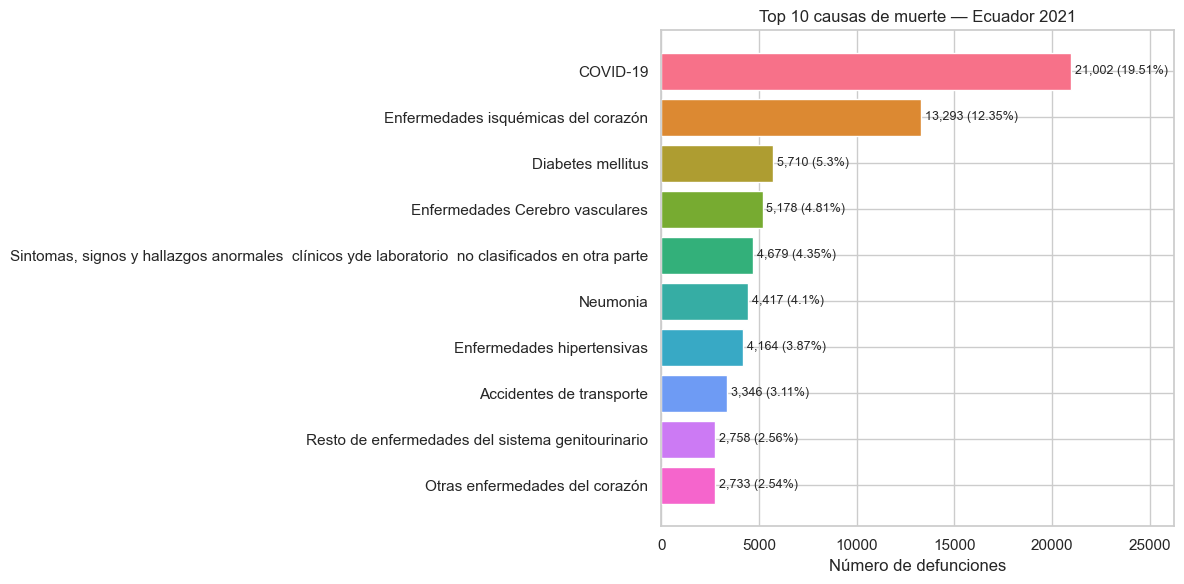

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    top10_causas["desc_causa103"],
    top10_causas["defunciones"],
    color=sns.color_palette("husl", 10)
)

ax.set_xlabel("Número de defunciones")
ax.set_title("Top 10 causas de muerte — Ecuador 2021")
ax.invert_yaxis()

for i, (val, pct) in enumerate(zip(top10_causas["defunciones"], top10_causas["porcentaje"])):
    ax.text(val + 200, i, f"{val:,} ({pct}%)", va="center", fontsize=9)

ax.set_xlim(0, top10_causas["defunciones"].iloc[0] * 1.25)
plt.tight_layout()
fig.savefig(PATH_FIGURES / "viz_01_top10_causas.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** El COVID-19 domina con 21,002 defunciones, separándose visualmente del resto. Las enfermedades isquémicas del corazón ocupan el segundo lugar con 13,293. A partir de la tercera posición, las barras se comprimen — las causas 3 a 10 tienen magnitudes similares (entre 2,733 y 5,710). Si se agruparan las cuatro causas cardiovasculares (isquémicas, cerebrovasculares, hipertensivas y otras del corazón), su barra combinada (25,368) superaría al COVID-19.

### Visualización 2 — Evolución mensual de defunciones

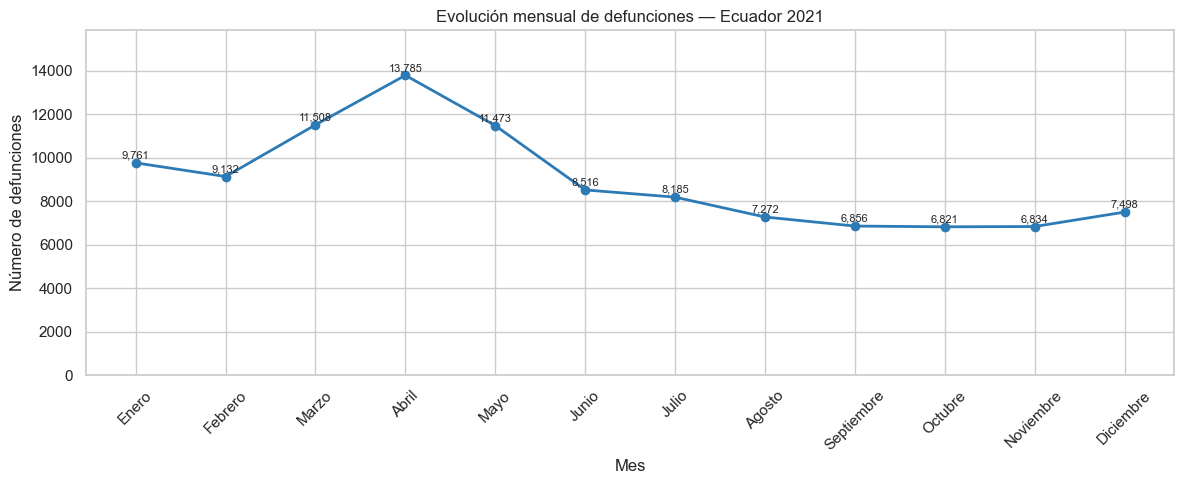

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    por_mes["mes_fall"],
    por_mes["defunciones"],
    marker="o",
    linewidth=2,
    color="#2c7bb6"
)

ax.set_xlabel("Mes")
ax.set_ylabel("Número de defunciones")
ax.set_title("Evolución mensual de defunciones — Ecuador 2021")
ax.tick_params(axis="x", rotation=45)

for i, val in enumerate(por_mes["defunciones"]):
    ax.text(i, val + 200, f"{val:,}", ha="center", fontsize=8)

ax.set_ylim(0, por_mes["defunciones"].max() * 1.15)
plt.tight_layout()
fig.savefig(PATH_FIGURES / "viz_02_evolucion_mensual.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** El gráfico confirma el pico de mortalidad en abril de 2021 (13,785 defunciones), con un ascenso marcado desde enero y un descenso progresivo hasta agosto. El segundo semestre se estabiliza entre 6,800 y 7,500 defunciones mensuales. La forma de la curva — ascenso rápido, descenso gradual — es el patrón típico de una ola epidémica.

### Visualización 3 — Distribución de edad al momento de defunción

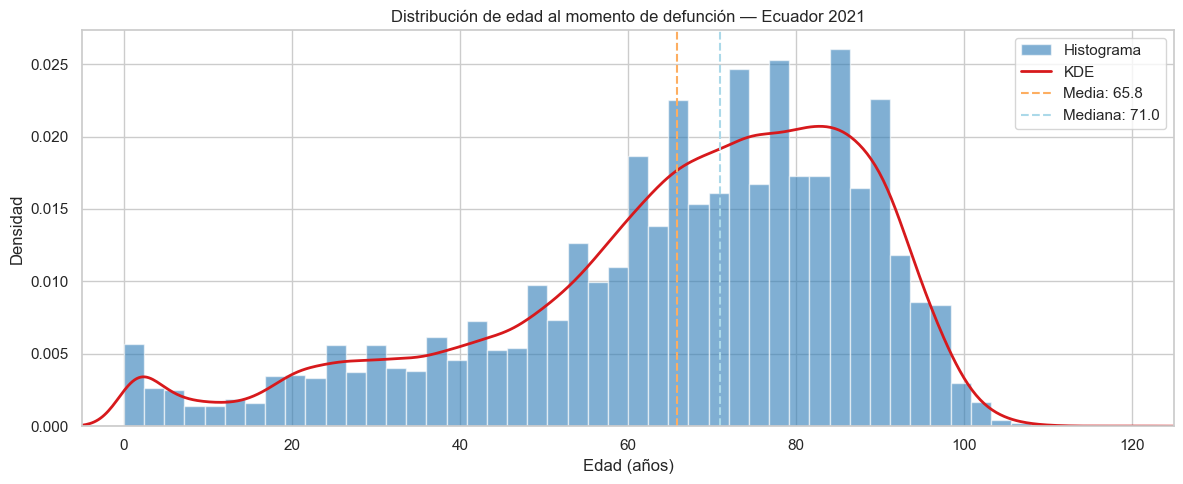

Media: 65.8 | Mediana: 71.0 | Desv. estándar: 22.7
Registros sin edad (excluidos): 49


In [20]:
edad_sin_nulos = df["edad"].dropna()

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    edad_sin_nulos,
    bins=50,
    density=True,
    alpha=0.6,
    color="#2c7bb6",
    edgecolor="white",
    label="Histograma"
)

edad_sin_nulos.plot.kde(ax=ax, linewidth=2, color="#d7191c", label="KDE")

media = edad_sin_nulos.mean()
mediana = edad_sin_nulos.median()
ax.axvline(media, color="#fdae61", linestyle="--", linewidth=1.5, label=f"Media: {media:.1f}")
ax.axvline(mediana, color="#abd9e9", linestyle="--", linewidth=1.5, label=f"Mediana: {mediana:.1f}")

ax.set_xlabel("Edad (años)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de edad al momento de defunción — Ecuador 2021")
ax.set_xlim(-5, 125)
ax.legend()

plt.tight_layout()
fig.savefig(PATH_FIGURES / "viz_03_distribucion_edad.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Media: {media:.1f} | Mediana: {mediana:.1f} | Desv. estándar: {edad_sin_nulos.std():.1f}")
print(f"Registros sin edad (excluidos): {df['edad'].isnull().sum()}")

**Interpretación:** La distribución presenta asimetría negativa (cola izquierda más larga), con la mayor concentración de defunciones entre los 60 y 90 años. La mediana (71.0) supera a la media (65.8) en 5.2 años, lo que confirma la asimetría: las defunciones en edades tempranas (pico neonatal cerca de 0 y muertes entre 15-40 años) arrastran la media hacia abajo. La desviación estándar de 22.7 años indica una dispersión considerable. El pequeño pico visible cerca de la edad 0 corresponde a defunciones neonatales e infantiles.

### Visualización 4 — Distribución de edad por sexo

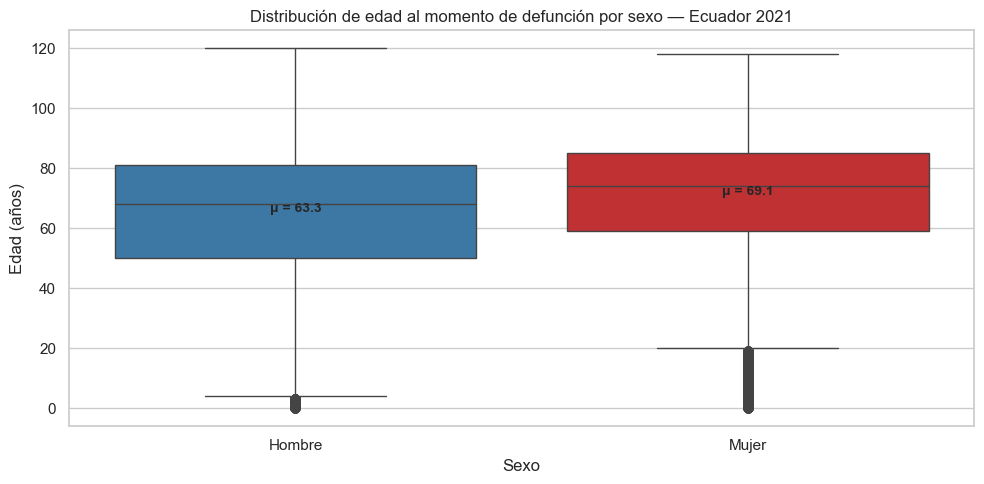

In [22]:
df_edad_sexo = df[df["sexo"].isin(["Hombre", "Mujer"]) & df["edad"].notna()]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df_edad_sexo,
    x="sexo",
    y="edad",
    hue="sexo",
    palette=["#2c7bb6", "#d7191c"],
    legend=False,
    ax=ax
)

ax.set_xlabel("Sexo")
ax.set_ylabel("Edad (años)")
ax.set_title("Distribución de edad al momento de defunción por sexo — Ecuador 2021")

medias = df_edad_sexo.groupby("sexo")["edad"].mean()
for i, sexo in enumerate(["Hombre", "Mujer"]):
    ax.text(i, medias[sexo] + 2, f"μ = {medias[sexo]:.1f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
fig.savefig(PATH_FIGURES / "viz_04_edad_por_sexo.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** Las mujeres presentan una edad promedio de defunción de 69.1 años frente a 63.3 de los hombres — una diferencia de 5.8 años, consistente con la mayor esperanza de vida femenina en Ecuador. La caja de los hombres es más amplia (mayor rango intercuartílico), indicando mayor dispersión en la edad de muerte. Esto se explica en parte por la mayor incidencia masculina de mortalidad prematura: accidentes de transporte, violencia y COVID-19 con mayor severidad en hombres, que arrastran la media masculina hacia abajo. Los outliers inferiores en ambos sexos corresponden a defunciones infantiles y neonatales.

### Visualización 5 — Matriz de correlación de variables numéricas

**Elección del coeficiente de correlación.** Antes de calcular una matriz de correlación es necesario preguntarse qué tipo de relación se busca medir y qué supuestos cumplen las variables:

- **Pearson** ($r$) mide relaciones estrictamente lineales y asume variables continuas con distribución aproximadamente normal.
- **Spearman** ($\rho_s$) mide relaciones monótonas (no necesariamente lineales) operando sobre los rangos de los datos. Es robusto ante outliers y no requiere normalidad.
- **Kendall** ($\tau$) mide concordancia entre pares ordenados. Es más robusto con muestras pequeñas pero computacionalmente más costoso.

En este dataset, las variables numéricas son mayoritariamente **discretas** (componentes temporales como año, día y mes) y la única variable continua con significado de magnitud es `edad`. Además, existen 7 registros con edades superiores a 115 años. Por estas razones, **Spearman es la elección apropiada**.

**Exclusión de códigos nominales.** Se excluyen las columnas `cod_causa103`, `cod_causa80` y `cod_causa67B` porque son **códigos nominales**: sus valores numéricos son etiquetas arbitrarias de la clasificación CIE-10, no magnitudes que representen un orden o rango. Calcular correlación sobre ellas produciría valores numéricos pero sin significado analítico — la "correlación" entre dos códigos arbitrarios no nos dice nada sobre relación causal o demográfica. La matriz se calcula solo sobre las 7 variables que tienen sentido cuantitativo: fechas (componentes temporales) y edad.

Aun con estas precauciones, varias correlaciones serán triviales por construcción — por ejemplo, $\text{edad} \approx 2021 - \text{anio\_nac}$, lo que implica $\rho_s \approx -1$ sin aportar información nueva.

In [ ]:
cols_numericas = ["edad", "anio_nac", "dia_nac", "anio_fall", "dia_fall",
                  "anio_insc", "dia_insc"]

corr = df[cols_numericas].corr(method="spearman")

# Usar clustermap para agregar dendrograma de clustering jerárquico
g = sns.clustermap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    figsize=(10, 8),
    cbar_kws={"shrink": 0.8}
)

g.set_title("Matriz de correlación de Spearman — Variables numéricas\n(reordenada por clustering jerárquico)")
plt.tight_layout()
plt.savefig(PATH_FIGURES / "viz_05_matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** La matriz confirma las limitaciones anticipadas. Las tres correlaciones fuera de la diagonal son:

1. **`edad` ↔ `anio_nac`** ($\rho_s = -1.00$): trivial por construcción — la edad se calcula como $2021 - \text{anio\_nac}$, por lo que la correlación perfecta negativa es una identidad algebraica, no un hallazgo.
2. **`dia_fall` ↔ `dia_insc`** ($\rho_s = 0.66$): correlación moderada que indica que una proporción considerable de defunciones se inscriben el mismo día del fallecimiento o en días cercanos. Es un patrón administrativo del registro civil.
3. **Todas las demás correlaciones** son inferiores a 0.04 en valor absoluto, indicando independencia práctica entre las variables temporales restantes.

Este resultado ilustra una realidad frecuente en datasets demográficos: las variables numéricas disponibles son componentes temporales o códigos, no mediciones independientes. Esto no significa que el análisis cuantitativo sea limitado, sino que la correlación no es la herramienta adecuada para estas variables. La asociación entre variables categóricas (que constituyen 43 de las 58 columnas) se analiza de forma más informativa mediante tablas de contingencia, proporciones condicionales y visualizaciones de composición, que se abordan a continuación.

## 5. Visualizaciones exploratorias complementarias

### Visualización 6 — Nivel de instrucción por grupo etario

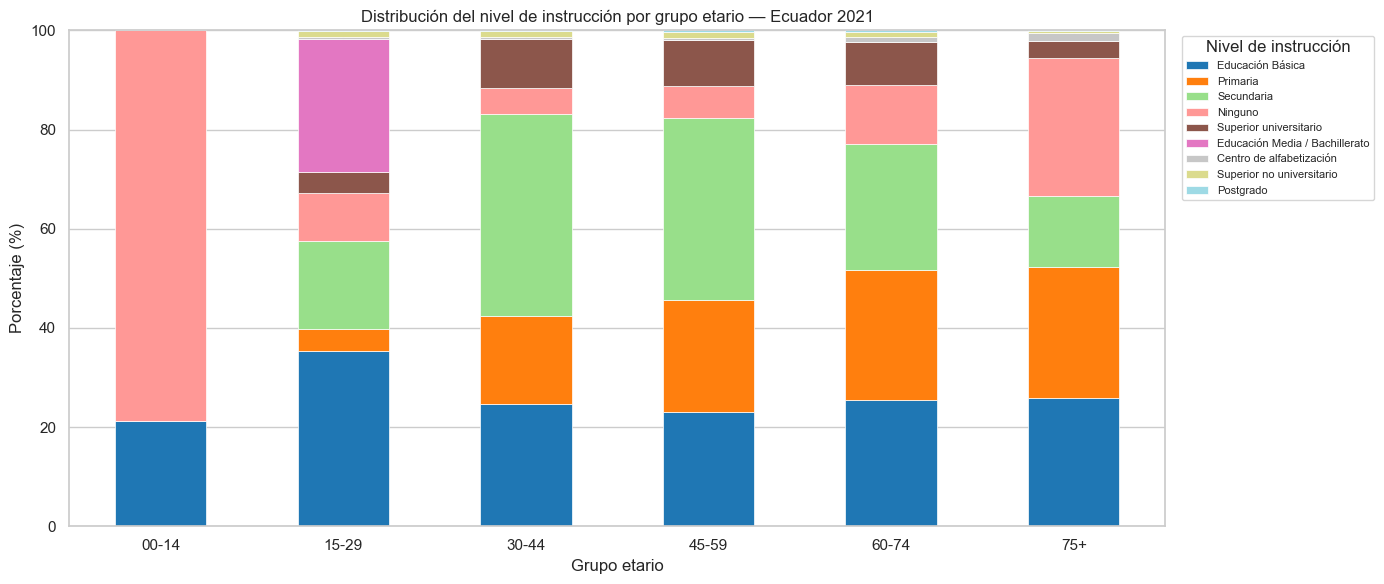

In [25]:
df_ei = df[df["edad"].notna() & df["niv_inst"].notna()].copy()

df_ei["grupo_etario"] = pd.cut(
    df_ei["edad"],
    bins=[0, 14, 29, 44, 59, 74, float("inf")],
    labels=["00-14", "15-29", "30-44", "45-59", "60-74", "75+"],
    right=True
)

tabla_cruzada = pd.crosstab(
    df_ei["grupo_etario"],
    df_ei["niv_inst"],
    normalize="index"
) * 100

columnas_ordenadas = (
    df_ei["niv_inst"]
    .value_counts()
    .index
    .tolist()
)
tabla_cruzada = tabla_cruzada[columnas_ordenadas]

fig, ax = plt.subplots(figsize=(14, 6))

tabla_cruzada.plot.bar(
    stacked=True,
    ax=ax,
    colormap="tab20",
    edgecolor="white",
    linewidth=0.5
)

ax.set_xlabel("Grupo etario")
ax.set_ylabel("Porcentaje (%)")
ax.set_title("Distribución del nivel de instrucción por grupo etario — Ecuador 2021")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Nivel de instrucción", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
fig.savefig(PATH_FIGURES / "viz_06_instruccion_grupo_etario.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** El gráfico revela la evolución histórica del acceso educativo en Ecuador. En el grupo 00-14, "Ninguno" predomina (~78%) porque son menores que aún no completan niveles formales. En 15-29, "Educación Básica" y "Educación Media/Bachillerato" dominan, reflejando la cobertura educativa actual. A partir de 45-59, "Primaria" crece progresivamente y "Ninguno" reaparece con fuerza en el grupo 75+ (~35%), evidenciando las menores tasas de escolarización de generaciones nacidas antes de 1946. "Superior universitario" y "Postgrado" son visibles pero marginales en todos los grupos, lo que refleja la realidad de acceso a educación superior en el país.

### Visualización 7 — Tasa de mortalidad violenta por provincia

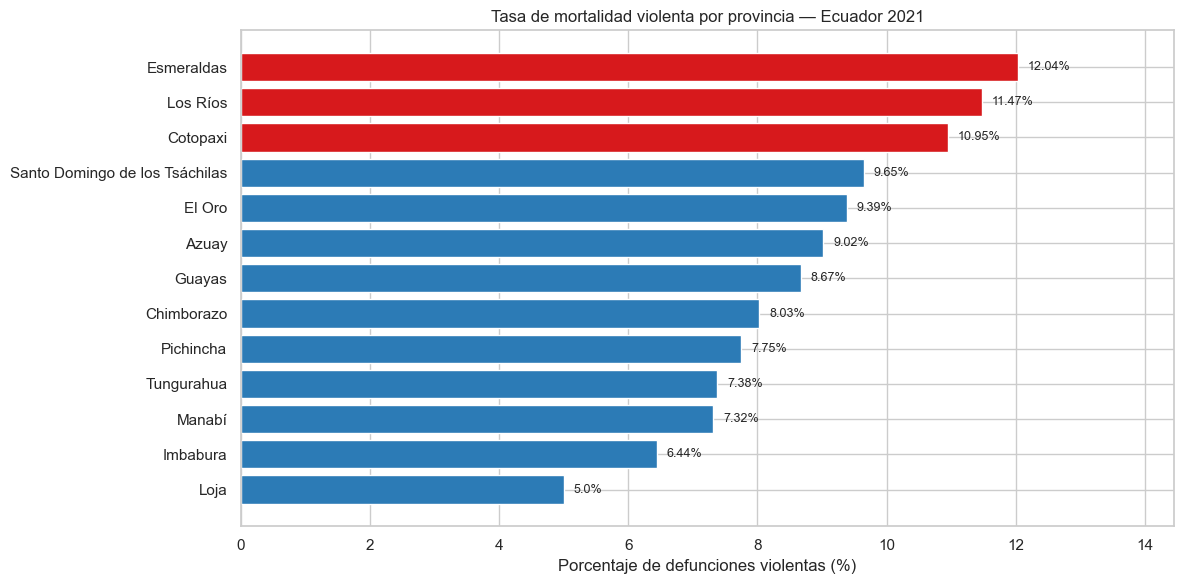

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

colores = ["#d7191c" if pct >= 10 else "#2c7bb6" for pct in mortalidad_violenta["pct_violentas"]]

ax.barh(
    mortalidad_violenta["prov_fall"],
    mortalidad_violenta["pct_violentas"],
    color=colores
)

ax.set_xlabel("Porcentaje de defunciones violentas (%)")
ax.set_title("Tasa de mortalidad violenta por provincia — Ecuador 2021")
ax.invert_yaxis()

for i, val in enumerate(mortalidad_violenta["pct_violentas"]):
    ax.text(val + 0.15, i, f"{val}%", va="center", fontsize=9)

ax.set_xlim(0, mortalidad_violenta["pct_violentas"].max() * 1.2)
plt.tight_layout()
fig.savefig(PATH_FIGURES / "viz_07_mortalidad_violenta_provincia.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** Esmeraldas (12.04%), Los Ríos (11.47%) y Cotopaxi (10.95%) presentan las tasas más altas de mortalidad violenta, destacadas en rojo. Loja registra la menor tasa (5.00%), menos de la mitad que Esmeraldas. Las dos provincias más pobladas — Guayas (8.67%) y Pichincha (7.75%) — se ubican en el rango medio, indicando que su alto volumen absoluto de muertes violentas refleja tamaño poblacional, no mayor incidencia relativa. La diferencia de 7 puntos porcentuales entre la provincia con mayor y menor tasa sugiere disparidades regionales significativas en seguridad pública e infraestructura vial.

### Visualización 8 — Distribución de edad por las 5 principales causas de muerte

In [ ]:
top5_causas = top10_causas["desc_causa103"].head(5).tolist()
df_top5 = df[df["desc_causa103"].isin(top5_causas) & df["edad"].notna()].copy()

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df_top5,
    x="desc_causa103",
    y="edad",
    hue="desc_causa103",
    palette="husl",
    legend=False,
    order=top5_causas,
    ax=ax
)

ax.set_xlabel("Causa de muerte")
ax.set_ylabel("Edad (años)")
ax.set_title("Distribución de edad por las 5 principales causas de muerte — Ecuador 2021")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=9)

plt.tight_layout()
fig.savefig(PATH_FIGURES / "viz_08_edad_por_causa.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** COVID-19 presenta la mediana más baja (~68 años) y el rango intercuartílico más amplio (Q1 ≈ 57, Q3 ≈ 82), lo que indica mayor dispersión — afectó un espectro etario más amplio que las otras causas. Las enfermedades isquémicas del corazón y cerebrovasculares muestran medianas más altas (~78 y ~77 respectivamente) con cajas más compactas, típico de enfermedades crónicas que se manifiestan en edades avanzadas. Diabetes mellitus tiene una concentración notable de outliers inferiores (casos entre 5 y 30 años), que corresponden a diabetes tipo 1 en población joven. La categoría de "Síntomas, signos y hallazgos anormales" replica un perfil similar al de las enfermedades crónicas, lo que sugiere que muchas de esas muertes sin diagnóstico claro podrían corresponder a causas cardiovasculares o metabólicas en adultos mayores.

### Visualización 9 — Defunciones por autoidentificación étnica

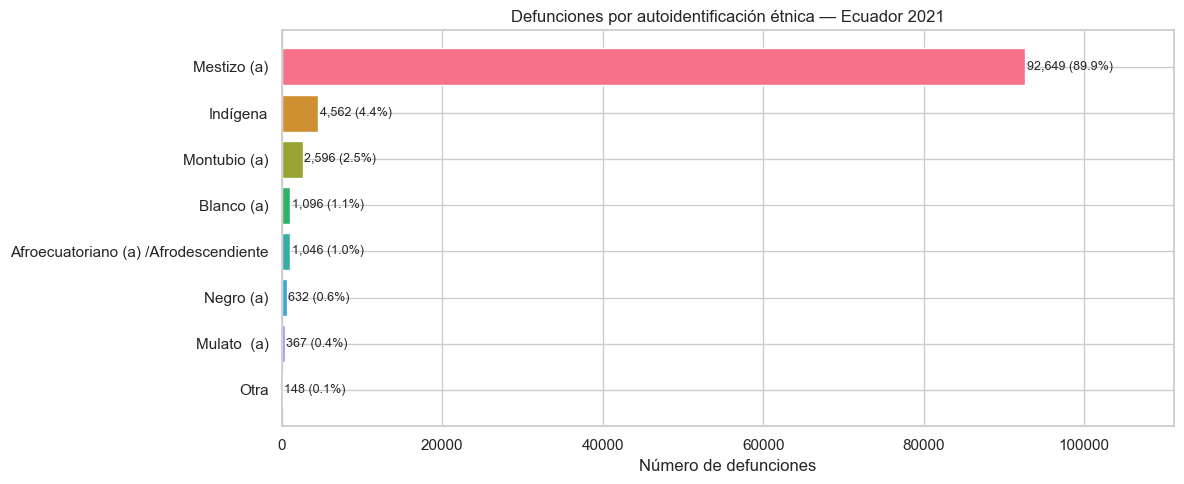

In [29]:
etnia_conteo = df["etnia"].dropna().value_counts()

fig, ax = plt.subplots(figsize=(12, 5))

ax.barh(
    etnia_conteo.index,
    etnia_conteo.values,
    color=sns.color_palette("husl", len(etnia_conteo))
)

ax.set_xlabel("Número de defunciones")
ax.set_title("Defunciones por autoidentificación étnica — Ecuador 2021")
ax.invert_yaxis()

for i, val in enumerate(etnia_conteo.values):
    pct = val / etnia_conteo.sum() * 100
    ax.text(val + 200, i, f"{val:,} ({pct:.1f}%)", va="center", fontsize=9)

ax.set_xlim(0, etnia_conteo.values[0] * 1.2)
plt.tight_layout()
fig.savefig(PATH_FIGURES / "viz_09_defunciones_etnia.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** La distribución refleja la composición étnica de Ecuador según autoidentificación: Mestizo(a) concentra el 89.9% de las defunciones con dato registrado. Indígena (4.4%) y Montubio(a) (2.5%) ocupan el segundo y tercer lugar. Es importante notar que esta variable tiene 4,545 nulos (4.22% del dataset), y que la autoidentificación en registros administrativos puede diferir de la composición censal real. Estos datos no permiten calcular tasas de mortalidad por grupo étnico — para ello se necesitaría el denominador poblacional de cada grupo, que no está incluido en este dataset.

## 6. Conclusiones

### Hallazgos principales

1. **COVID-19 fue la primera causa de muerte** con 21,002 defunciones (19.51%), pero las enfermedades cardiovasculares agrupadas (isquémicas, cerebrovasculares, hipertensivas y otras del corazón) superan al COVID-19 con 25,368 casos (23.57%).

2. **La mortalidad se concentra geográficamente:** Guayas y Pichincha acumulan el 46.13% de las defunciones. La tasa de mortalidad violenta varía significativamente entre provincias: Esmeraldas (12.04%) duplica a Loja (5.00%).

3. **El pico de abril de 2021** (13,785 defunciones) duplicó la mortalidad de los meses estables del segundo semestre (~7,000), confirmando el impacto de la tercera ola de COVID-19 en Ecuador.

4. **Las mujeres fallecen en promedio 5.8 años más tarde que los hombres** (69.1 vs 63.3 años), con mayor mortalidad masculina por COVID-19 (55% más) y mortalidad prematura por causas externas.

5. **La distribución del nivel de instrucción varía entre generaciones:** el grupo 75+ muestra ~35% sin escolaridad formal frente a menos del 10% en el grupo 15-29, reflejando la expansión histórica del sistema educativo ecuatoriano.

6. **La correlación entre variables numéricas es limitada** por la naturaleza del dataset (componentes temporales y códigos). Se utilizó el coeficiente de Spearman por ser más apropiado para variables discretas, y se excluyeron los códigos nominales CIE-10 que producirían correlaciones espurias.

### Limitaciones

- Las edades máximas registradas (hasta 120 años, 7 casos) podrían ser errores de la fuente original que no es posible confirmar sin acceso al registro primario.
- La variable de autoidentificación étnica no permite calcular tasas por grupo sin un denominador poblacional externo.
- La categoría "Síntomas, signos y hallazgos anormales" (4.35% de defunciones) indica un margen de subregistro diagnóstico que podría redistribuir casos hacia otras causas.

### Preguntas abiertas para análisis futuros

- ¿Cómo se compara la distribución de causas de muerte de 2021 con años no pandémicos?
- ¿Existe asociación estadística entre provincia y causa de muerte (test $\chi^2$ o $V$ de Cramér)?
- ¿La mortalidad violenta tiene un patrón estacional diferente al de las causas naturales?